# Classifying Alzheimer's Disease Using Deep Learning on fMRI
## Data Visualization and Classical ML Baselines

**Student:** Kirankumar Chikkamankanala Somashekar
**Programme:** MSc Advanced Computer Science, University of Strathclyde
**Supervisor:** Prof. Keith Smith
**Date:** August 26, 2026
**Version:** v1
**Dataset:** V4 Final (Schaefer 100 + Tian S2, 132 ROIs, 262 subjects)

---

**Contents:**
1. Setup and Configuration
2. Data Loading and Verification
3. Dataset Statistics and Demographics
4. Data Visualization
5. Classical ML Baselines (SVM Linear, SVM RBF, Random Forest)
6. Results Visualization
7. Save All Results

## 1. Setup and Configuration

### 1.1 Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1.2 Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import pickle
import os
import time
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy import stats

warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
})
np.random.seed(42)

print('Libraries imported.')
print(f'Started: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

Libraries imported.
Started: 2026-08-26 16:23:30


### 1.3 Paths and Directories

In [ ]:
# === DATA PATH ===
BASE = '/content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/data'

# === RESULTS DIRECTORY (notebook-specific) ===
RESULTS_BASE = '/content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results'
NB_RESULTS = os.path.join(RESULTS_BASE, 'nb01_baseline')
NB_FIGURES = os.path.join(NB_RESULTS, 'figures')
os.makedirs(NB_RESULTS, exist_ok=True)
os.makedirs(NB_FIGURES, exist_ok=True)

# === DATA FILES ===
FC_FEATURES   = f'{BASE}/X_features.npy'
FC_LABELS     = f'{BASE}/y_labels.npy'
FC_SUBJECTS   = f'{BASE}/subject_ids.npy'
GCN_MATRICES  = f'{BASE}/fc_matrices_stacked.npy'
BOLD_TR3      = f'{BASE}/X_bold_tr3.npy'
BOLD_TR3_LBL  = f'{BASE}/y_labels_tr3.npy'
CV_FOLDS      = f'{BASE}/cv_folds.pkl'
MANIFEST      = f'{BASE}/subject_manifest.csv'

print(f'Data:    {BASE}')
print(f'Results: {NB_RESULTS}')
print(f'Figures: {NB_FIGURES}')

Data:    /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/data
Results: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results/nb01_baseline
Figures: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results/nb01_baseline/figures


## 2. Data Loading and Verification

### 2.1 Load All Datasets

In [ ]:
print('Loading datasets...')
t0 = time.time()

X_fc = np.load(FC_FEATURES)                          # (262, 8646)
y_fc = np.load(FC_LABELS)                             # (262,)
subject_ids = np.load(FC_SUBJECTS, allow_pickle=True) # (262,)
fc_matrices = np.load(GCN_MATRICES)                   # (262, 132, 132)
X_bold = np.load(BOLD_TR3)                            # (218, 191, 132)
y_bold = np.load(BOLD_TR3_LBL)                        # (218,)

with open(CV_FOLDS, 'rb') as f:
    cv_folds = pickle.load(f)

manifest = pd.read_csv(MANIFEST)
cn_manifest = manifest[manifest['group'] == 'CN']
ad_manifest = manifest[manifest['group'] == 'AD']

N, M = X_fc.shape[0], fc_matrices.shape[1]

print(f'Loaded in {time.time()-t0:.1f}s')

Loading datasets...
Loaded in 9.0s


### 2.2 Data Verification

In [ ]:
print('Data Shapes')
print('=' * 55)
shapes = pd.DataFrame({
    'Dataset': ['FC Features (SVM/RF)', 'FC Labels', 'FC Matrices (GCN)',
                'BiLSTM BOLD (TR=3s)', 'BiLSTM Labels', 'Subject Manifest'],
    'Shape': [str(X_fc.shape), str(y_fc.shape), str(fc_matrices.shape),
              str(X_bold.shape), str(y_bold.shape), f'{manifest.shape[0]} rows x {manifest.shape[1]} cols'],
    'dtype': [str(X_fc.dtype), str(y_fc.dtype), str(fc_matrices.dtype),
              str(X_bold.dtype), str(y_bold.dtype), 'DataFrame'],
})
display(shapes.style.set_caption('Data Shapes').hide(axis='index').\
        set_properties(**{'text-align': 'left'}))

# Integrity checks
checks = {
    'FC features: no NaN': not np.any(np.isnan(X_fc)),
    'FC features: no Inf': not np.any(np.isinf(X_fc)),
    'GCN matrices: no NaN': not np.any(np.isnan(fc_matrices)),
    'GCN matrices: symmetric': np.allclose(fc_matrices, fc_matrices.transpose(0,2,1)),
    'GCN matrices: diagonal=0': np.allclose(np.diagonal(fc_matrices, axis1=1, axis2=2), 0),
    'BiLSTM: no NaN': not np.any(np.isnan(X_bold)),
    'Labels: FC == GCN': np.array_equal(y_fc, np.load(f'{BASE}/y_labels.npy')),
    'Labels: 131 CN + 131 AD': (y_fc==0).sum()==131 and (y_fc==1).sum()==131,
    'BiLSTM: 109 CN + 109 AD': (y_bold==0).sum()==109 and (y_bold==1).sum()==109,
    'CV folds: 5 folds': len(cv_folds)==5,
    'Manifest: 262 rows': len(manifest)==262,
}

check_df = pd.DataFrame({
    'Check': list(checks.keys()),
    'Status': ['PASS' if v else 'FAIL' for v in checks.values()]
})
print(f'\nIntegrity Checks: {sum(checks.values())}/{len(checks)} passed')
display(check_df.style.applymap(
    lambda x: 'color: green' if x=='PASS' else 'color: red',
    subset=['Status']).hide(axis='index'))

Data Shapes


Dataset,Shape,dtype
FC Features (SVM/RF),"(262, 8646)",float32
FC Labels,"(262,)",int64
FC Matrices (GCN),"(262, 132, 132)",float32
BiLSTM BOLD (TR=3s),"(218, 191, 132)",float32
BiLSTM Labels,"(218,)",int64
Subject Manifest,262 rows x 18 cols,DataFrame



Integrity Checks: 11/11 passed


Check,Status
FC features: no NaN,PASS
FC features: no Inf,PASS
GCN matrices: no NaN,PASS
GCN matrices: symmetric,PASS
GCN matrices: diagonal=0,PASS
BiLSTM: no NaN,PASS
Labels: FC == GCN,PASS
Labels: 131 CN + 131 AD,PASS
BiLSTM: 109 CN + 109 AD,PASS
CV folds: 5 folds,PASS


## 3. Dataset Statistics and Demographics

### 3.1 Class Distribution

In [ ]:
class_df = pd.DataFrame({
    'Dataset': ['Full (SVM/RF/GCN)', 'BiLSTM subset (TR=3.0s)'],
    'Total': [len(y_fc), len(y_bold)],
    'CN (label=0)': [int((y_fc==0).sum()), int((y_bold==0).sum())],
    'AD (label=1)': [int((y_fc==1).sum()), int((y_bold==1).sum())],
    'AD %': [f'{(y_fc==1).sum()/len(y_fc)*100:.1f}%', f'{(y_bold==1).sum()/len(y_bold)*100:.1f}%']
})
display(class_df.style.set_caption('Class Distribution').hide(axis='index').\
        set_properties(**{'text-align': 'center'}))

Dataset,Total,CN (label=0),AD (label=1),AD %
Full (SVM/RF/GCN),262,131,131,50.0%
BiLSTM subset (TR=3.0s),218,109,109,50.0%


### 3.2 Demographics by Diagnosis Group

In [ ]:
demo_rows = []
for gn, gd in [('CN (n=131)', cn_manifest), ('AD (n=131)', ad_manifest)]:
    row = {'Group': gn}
    row['Age (mean +/- std)'] = f'{gd["age"].mean():.1f} +/- {gd["age"].std():.1f}'
    row['Age range'] = f'{gd["age"].min()}-{gd["age"].max()}'
    if 'sex' in gd.columns:
        m = (gd['sex']==1).sum()
        f = (gd['sex']==2).sum()
        row['Male / Female'] = f'{m} / {f}'
    if 'education' in gd.columns:
        row['Education (mean +/- std)'] = f'{gd["education"].mean():.1f} +/- {gd["education"].std():.1f}'
    if 'MMSE' in gd.columns:
        row['MMSE (mean +/- std)'] = f'{gd["MMSE"].mean():.1f} +/- {gd["MMSE"].std():.1f}'
    if 'CDR' in gd.columns:
        row['CDR (mean +/- std)'] = f'{gd["CDR"].mean():.2f} +/- {gd["CDR"].std():.2f}'
    demo_rows.append(row)

demo_df = pd.DataFrame(demo_rows)
display(demo_df.style.set_caption('Subject Demographics').hide(axis='index').\
        set_properties(**{'text-align': 'center'}))

# Save demographics table as CSV
demo_df.to_csv(os.path.join(NB_RESULTS, 'demographics_table.csv'), index=False)
print(f'Saved: demographics_table.csv')

Group,Age (mean +/- std),Age range,Male / Female,Education (mean +/- std),MMSE (mean +/- std),CDR (mean +/- std)
CN (n=131),76.6 +/- 8.3,58-93,74 / 57,17.1 +/- 2.3,28.9 +/- 1.3,0.03 +/- 0.13
AD (n=131),76.8 +/- 8.2,59-95,76 / 55,16.0 +/- 2.5,22.4 +/- 4.3,0.86 +/- 0.52


Saved: demographics_table.csv


### 3.3 Age and Sex Matching Verification

In [ ]:
age_t, age_p = stats.ttest_ind(cn_manifest['age'], ad_manifest['age'])
match_df = pd.DataFrame({
    'Variable': ['Age', 'Sex (% male)'],
    'CN': [f'{cn_manifest["age"].mean():.1f}', f'{(cn_manifest["sex"]==1).sum()/len(cn_manifest)*100:.1f}%'],
    'AD': [f'{ad_manifest["age"].mean():.1f}', f'{(ad_manifest["sex"]==1).sum()/len(ad_manifest)*100:.1f}%'],
    'Test': [f't={age_t:.3f}, p={age_p:.3f}', '-'],
    'Matched?': ['Yes' if age_p > 0.05 else 'No', 'Yes']
})
display(match_df.style.set_caption('Group Matching Verification').hide(axis='index').\
        set_properties(**{'text-align': 'center'}))

print(f'\nTR distribution:')
display(manifest['TR'].value_counts().to_frame().style.set_caption('TR Protocol Distribution'))

print(f'\nTime points (T): min={manifest["T"].min()}, max={manifest["T"].max()}, '
      f'median={manifest["T"].median():.0f}')

Variable,CN,AD,Test,Matched?
Age,76.6,76.8,"t=-0.202, p=0.840",Yes
Sex (% male),56.5%,58.0%,-,Yes



TR distribution:


,count
TR,
3.000000,218
0.607000,42
0.788000,2



Time points (T): min=191, max=976, median=197


## 4. Data Visualization

### 4.1 AD vs CN Class Distribution

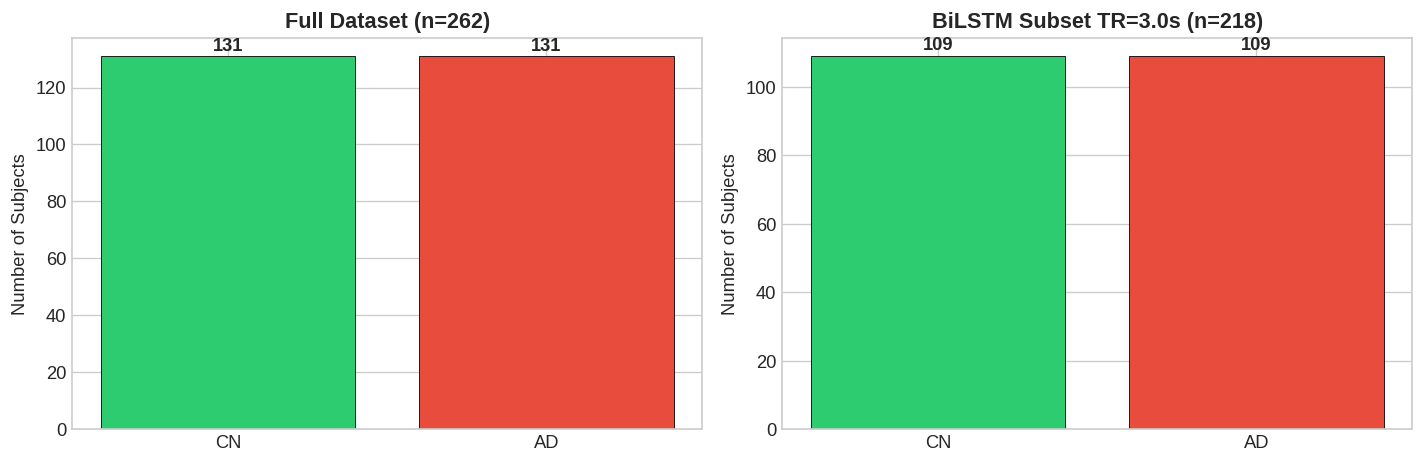

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#2ecc71', '#e74c3c']

for ax, data, title in [(axes[0], y_fc, 'Full Dataset (n=262)'),
                         (axes[1], y_bold, 'BiLSTM Subset TR=3.0s (n=218)')]:
    counts = [int((data==0).sum()), int((data==1).sum())]
    bars = ax.bar(['CN', 'AD'], counts, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title)
    ax.set_ylabel('Number of Subjects')
    for bar, v in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, v+2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(NB_FIGURES, 'class_distribution.png'))
plt.show()

### 4.2 Age Distribution by Diagnosis Group

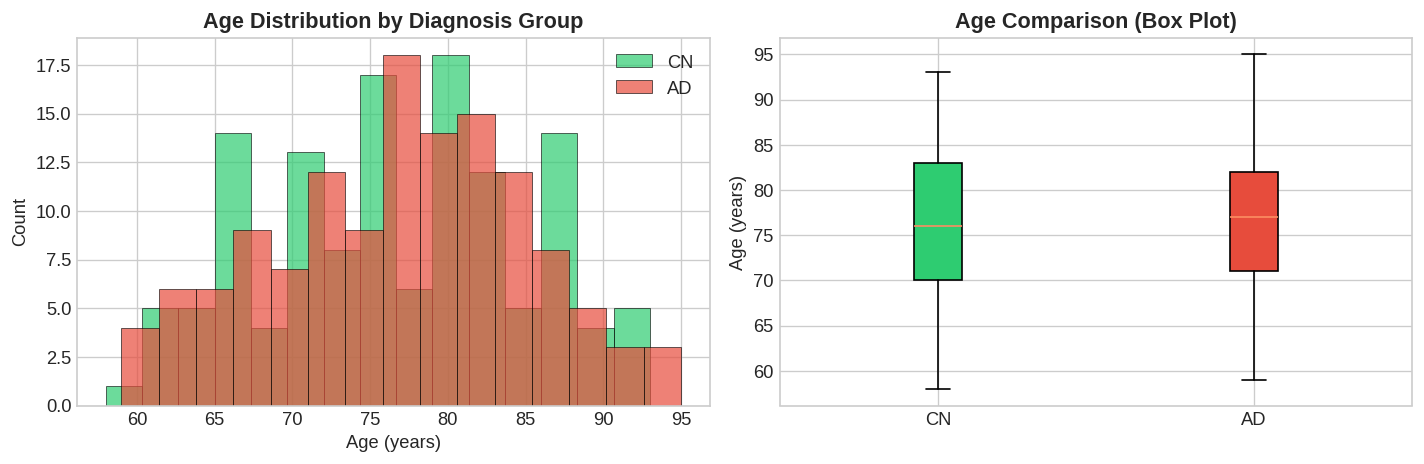

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(cn_manifest['age'], bins=15, alpha=0.7, label='CN', color='#2ecc71', edgecolor='black', linewidth=0.5)
axes[0].hist(ad_manifest['age'], bins=15, alpha=0.7, label='AD', color='#e74c3c', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Age (years)'); axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution by Diagnosis Group'); axes[0].legend()

bp = axes[1].boxplot([cn_manifest['age'].values, ad_manifest['age'].values],
                     labels=['CN','AD'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71'); bp['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_ylabel('Age (years)'); axes[1].set_title('Age Comparison (Box Plot)')

plt.tight_layout()
plt.savefig(os.path.join(NB_FIGURES, 'age_distribution.png'))
plt.show()

### 4.3 Sex Distribution by Diagnosis Group

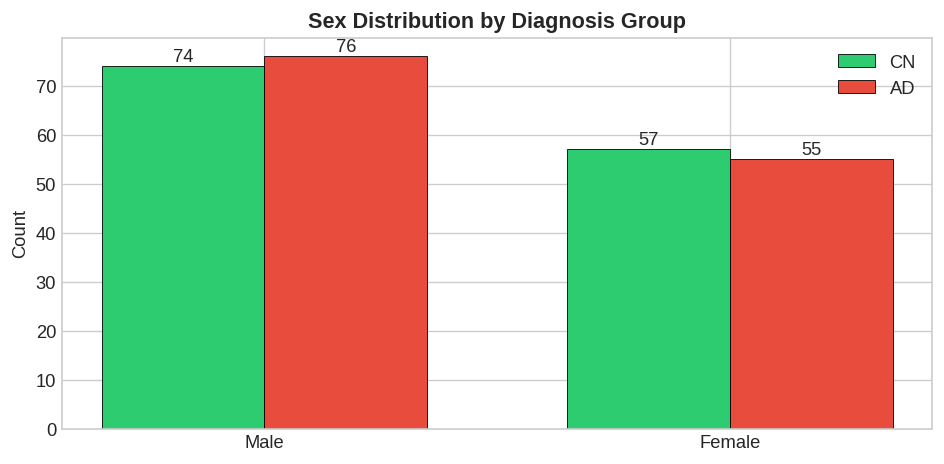

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
cn_sex = [(cn_manifest['sex']==1).sum(), (cn_manifest['sex']==2).sum()]
ad_sex = [(ad_manifest['sex']==1).sum(), (ad_manifest['sex']==2).sum()]
x = np.arange(2); w = 0.35
b1 = ax.bar(x-w/2, cn_sex, w, label='CN', color='#2ecc71', edgecolor='black', linewidth=0.5)
b2 = ax.bar(x+w/2, ad_sex, w, label='AD', color='#e74c3c', edgecolor='black', linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(['Male','Female'])
ax.set_ylabel('Count'); ax.set_title('Sex Distribution by Diagnosis Group'); ax.legend()
for b in b1+b2: ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, int(b.get_height()), ha='center')
plt.tight_layout()
plt.savefig(os.path.join(NB_FIGURES, 'sex_distribution.png'))
plt.show()

### 4.4 MMSE and CDR Clinical Score Distributions

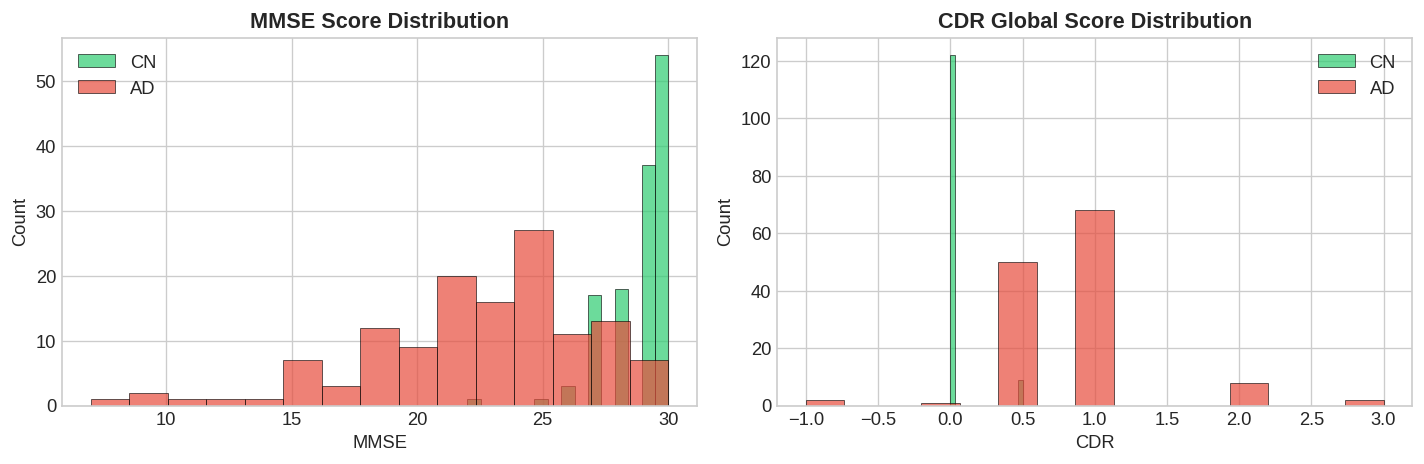

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in [(axes[0], 'MMSE', 'MMSE Score Distribution'),
                        (axes[1], 'CDR', 'CDR Global Score Distribution')]:
    ax.hist(cn_manifest[col].dropna(), bins=15, alpha=0.7, label='CN', color='#2ecc71', edgecolor='black', linewidth=0.5)
    ax.hist(ad_manifest[col].dropna(), bins=15, alpha=0.7, label='AD', color='#e74c3c', edgecolor='black', linewidth=0.5)
    ax.set_xlabel(col); ax.set_ylabel('Count'); ax.set_title(title); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(NB_FIGURES, 'clinical_scores.png'))
plt.show()

### 4.5 Sample Functional Connectivity Matrices (CN vs AD)

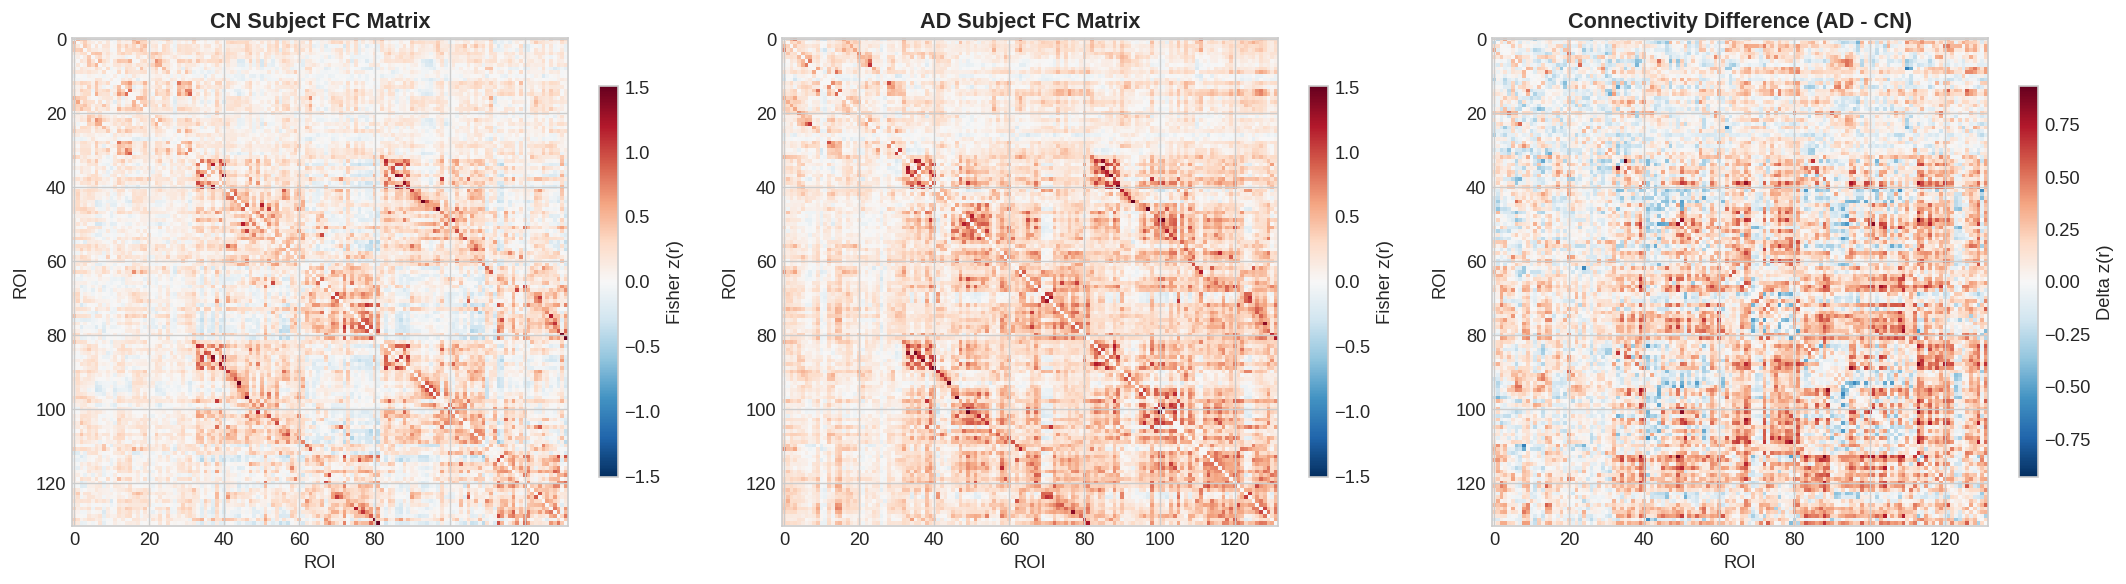

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cn_i, ad_i = np.where(y_fc==0)[0][0], np.where(y_fc==1)[0][0]
vmax = max(abs(fc_matrices[cn_i].min()), abs(fc_matrices[cn_i].max()))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

for ax, mat, title in [(axes[0], fc_matrices[cn_i], 'CN Subject FC Matrix'),
                        (axes[1], fc_matrices[ad_i], 'AD Subject FC Matrix')]:
    im = ax.imshow(mat, cmap='RdBu_r', norm=norm, aspect='auto')
    ax.set_title(title); ax.set_xlabel('ROI'); ax.set_ylabel('ROI')
    plt.colorbar(im, ax=ax, shrink=0.8, label='Fisher z(r)')

diff = fc_matrices[ad_i] - fc_matrices[cn_i]
vd = max(abs(diff.min()), abs(diff.max()))
if vd < 1e-10:
    vd = 1.0  # fallback if difference is near zero
im = axes[2].imshow(diff, cmap='RdBu_r', vmin=-vd, vmax=vd, aspect='auto')
axes[2].set_title('Connectivity Difference (AD - CN)'); axes[2].set_xlabel('ROI'); axes[2].set_ylabel('ROI')
plt.colorbar(im, ax=axes[2], shrink=0.8, label='Delta z(r)')
plt.tight_layout()
plt.savefig(os.path.join(NB_FIGURES, 'sample_fc_matrices.png'))
plt.show()

### 4.6 Group Mean Functional Connectivity

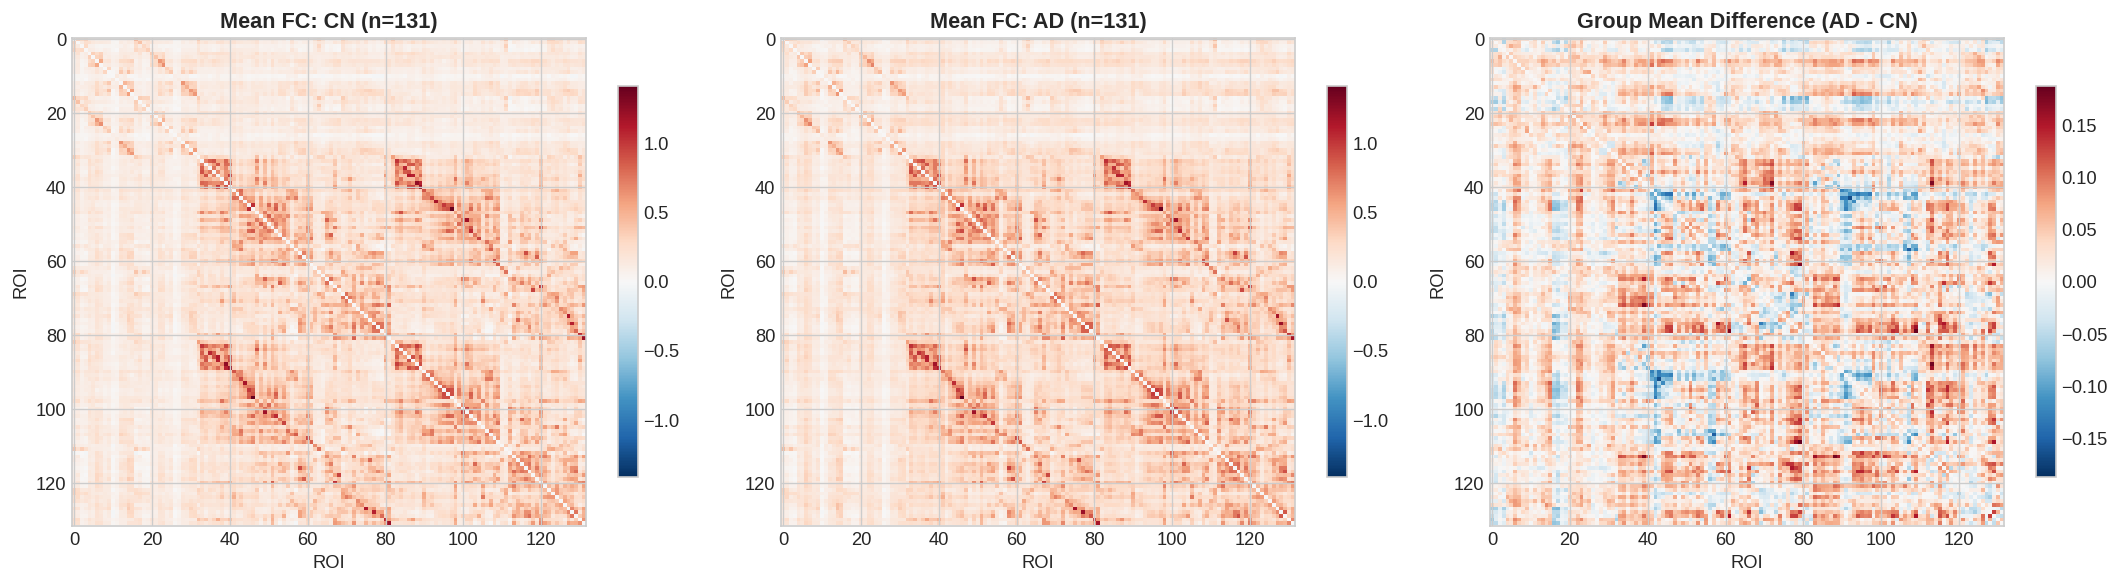

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
mean_cn = fc_matrices[y_fc==0].mean(0)
mean_ad = fc_matrices[y_fc==1].mean(0)
mean_diff = mean_ad - mean_cn
vm = max(abs(mean_cn.min()), abs(mean_cn.max()))
if vm < 1e-10: vm = 1.0

for ax, mat, title in [(axes[0], mean_cn, 'Mean FC: CN (n=131)'),
                        (axes[1], mean_ad, 'Mean FC: AD (n=131)')]:
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-vm, vmax=vm, aspect='auto')
    ax.set_title(title); ax.set_xlabel('ROI'); ax.set_ylabel('ROI')
    plt.colorbar(im, ax=ax, shrink=0.8)

vd = max(abs(mean_diff.min()), abs(mean_diff.max()))
if vd < 1e-10: vd = 1.0
im = axes[2].imshow(mean_diff, cmap='RdBu_r', vmin=-vd, vmax=vd, aspect='auto')
axes[2].set_title('Group Mean Difference (AD - CN)'); axes[2].set_xlabel('ROI'); axes[2].set_ylabel('ROI')
plt.colorbar(im, ax=axes[2], shrink=0.8)
plt.tight_layout()
plt.savefig(os.path.join(NB_FIGURES, 'mean_fc_matrices.png'))
plt.show()

### 4.7 PCA and t-SNE of FC Features

Computing t-SNE...


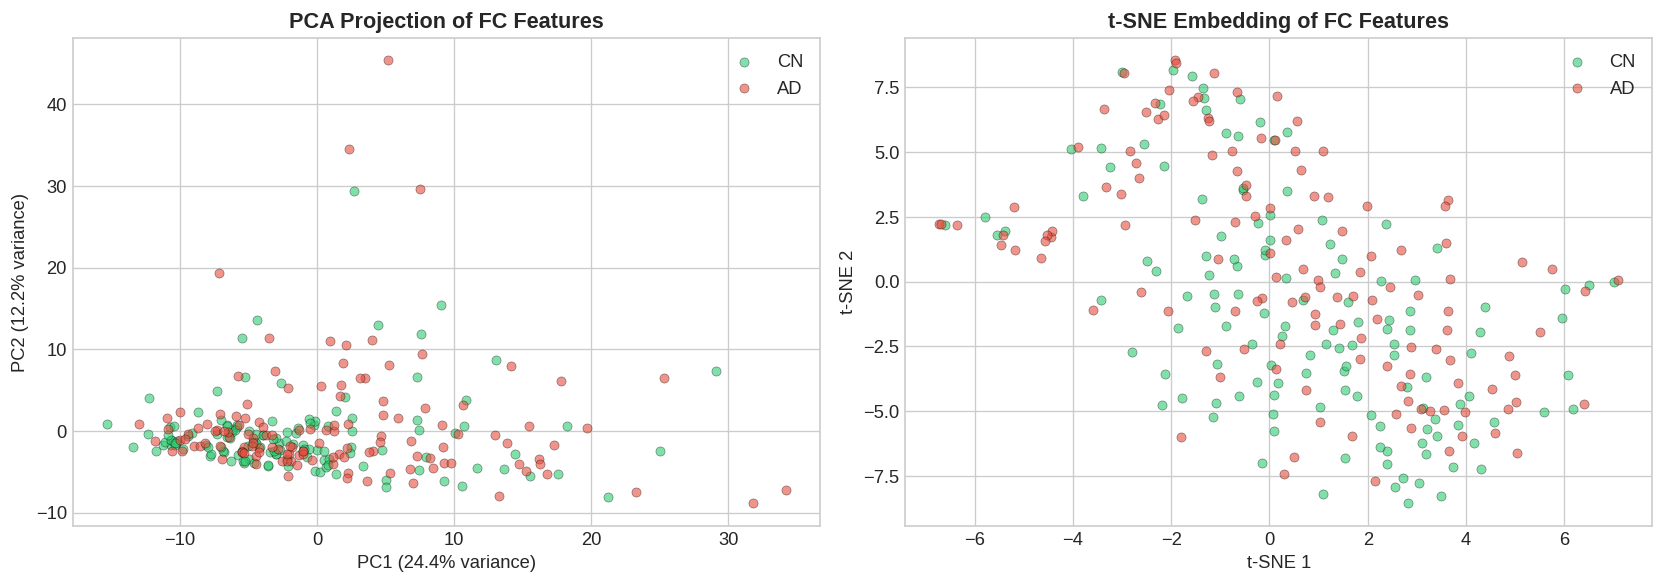

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_fc)
for label, color, name in [(0,'#2ecc71','CN'),(1,'#e74c3c','AD')]:
    mask = y_fc == label
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1], c=color, label=name, alpha=0.6, s=30, edgecolors='black', linewidth=0.3)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].set_title('PCA Projection of FC Features'); axes[0].legend()

print('Computing t-SNE...')
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_fc)
for label, color, name in [(0,'#2ecc71','CN'),(1,'#e74c3c','AD')]:
    mask = y_fc == label
    axes[1].scatter(X_tsne[mask,0], X_tsne[mask,1], c=color, label=name, alpha=0.6, s=30, edgecolors='black', linewidth=0.3)
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('t-SNE Embedding of FC Features'); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(NB_FIGURES, 'pca_tsne_projection.png'))
plt.show()

### 4.8 Sample BOLD Time Series (CN vs AD)

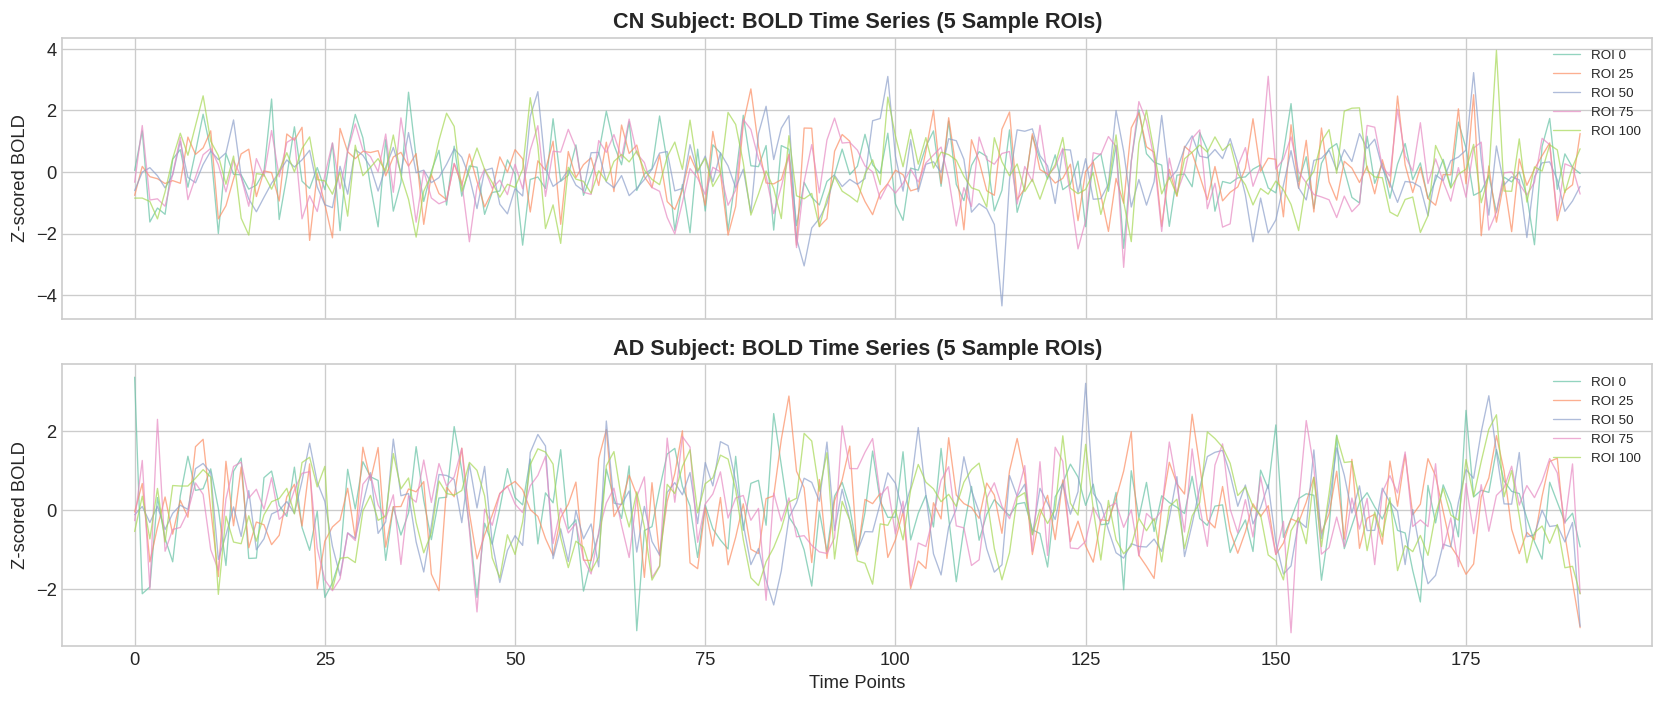

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
cn_bi, ad_bi = np.where(y_bold==0)[0][0], np.where(y_bold==1)[0][0]
rois = [0, 25, 50, 75, 100]
t_ax = np.arange(X_bold.shape[1])

for roi in rois: axes[0].plot(t_ax, X_bold[cn_bi,:,roi], alpha=0.7, linewidth=0.8)
axes[0].set_ylabel('Z-scored BOLD'); axes[0].set_title('CN Subject: BOLD Time Series (5 Sample ROIs)')
axes[0].legend([f'ROI {r}' for r in rois], loc='upper right', fontsize=8)

for roi in rois: axes[1].plot(t_ax, X_bold[ad_bi,:,roi], alpha=0.7, linewidth=0.8)
axes[1].set_xlabel('Time Points'); axes[1].set_ylabel('Z-scored BOLD')
axes[1].set_title('AD Subject: BOLD Time Series (5 Sample ROIs)')
axes[1].legend([f'ROI {r}' for r in rois], loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(NB_FIGURES, 'sample_bold_timeseries.png'))
plt.show()

### 4.9 Cross-Validation Fold Distribution

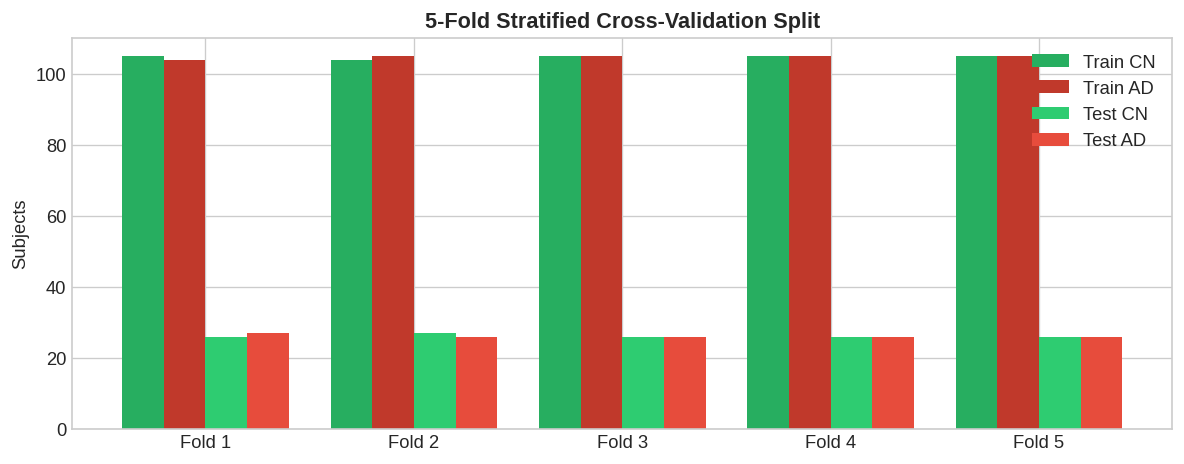

,Fold,Train CN,Train AD,Test CN,Test AD
0,Fold 1,105,104,26,27
1,Fold 2,104,105,27,26
2,Fold 3,105,105,26,26
3,Fold 4,105,105,26,26
4,Fold 5,105,105,26,26


In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
fold_data = []
for i, (tr,te) in enumerate(cv_folds):
    fold_data.append({'Fold': f'Fold {i+1}',
        'Train CN': int((y_fc[tr]==0).sum()), 'Train AD': int((y_fc[tr]==1).sum()),
        'Test CN': int((y_fc[te]==0).sum()), 'Test AD': int((y_fc[te]==1).sum())})
fd = pd.DataFrame(fold_data)
x = np.arange(5); w = 0.2
ax.bar(x-1.5*w, fd['Train CN'], w, label='Train CN', color='#27ae60')
ax.bar(x-0.5*w, fd['Train AD'], w, label='Train AD', color='#c0392b')
ax.bar(x+0.5*w, fd['Test CN'], w, label='Test CN', color='#2ecc71')
ax.bar(x+1.5*w, fd['Test AD'], w, label='Test AD', color='#e74c3c')
ax.set_xticks(x); ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylabel('Subjects'); ax.set_title('5-Fold Stratified Cross-Validation Split'); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(NB_FIGURES, 'cv_fold_distribution.png'))
plt.show()

display(fd.style.set_caption('CV Fold Breakdown').set_properties(**{'text-align':'center'}))

## 5. Classical ML Baselines

### 5.1 Evaluation Function

In [ ]:
def evaluate_model_cv(model_class, model_params, X, y, folds, model_name, scale=False):
    """
    Train and evaluate sklearn classifier with 5-fold CV.
    Returns standardised results dictionary.
    """
    t_start = time.time()
    metrics = {k: [] for k in ['accuracy','f1','precision','recall','auc_roc']}
    all_true, all_pred, all_prob = [], [], []

    print(f'\n{"="*55}')
    print(f'MODEL: {model_name}')
    print(f'Params: {model_params}')
    print(f'Data: {X.shape}, Scale: {scale}')
    print(f'{"="*55}')

    for fi, (tr, te) in enumerate(folds):
        X_tr, X_te = X[tr], X[te]
        y_tr, y_te = y[tr], y[te]

        if scale:
            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)

        model = model_class(**model_params)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:,1] if hasattr(model,'predict_proba') else \
                 model.decision_function(X_te) if hasattr(model,'decision_function') else y_pred.astype(float)

        acc = accuracy_score(y_te, y_pred)
        f1 = f1_score(y_te, y_pred, average='macro')
        prec = precision_score(y_te, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_te, y_pred, average='macro', zero_division=0)
        auc_v = roc_auc_score(y_te, y_prob)

        for k, v in zip(metrics.keys(), [acc,f1,prec,rec,auc_v]): metrics[k].append(v)
        all_true.extend(y_te.tolist()); all_pred.extend(y_pred.tolist()); all_prob.extend(y_prob.tolist())

        print(f'  Fold {fi+1}: Acc={acc:.4f}  F1={f1:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  AUC={auc_v:.4f}')

    elapsed = time.time() - t_start

    results = {
        'model_name': model_name, 'model_type': 'classical_ml',
        'n_subjects': len(y), 'n_features': X.shape[1],
        'config': model_params, 'training_time_seconds': elapsed,
        'y_true_all': all_true, 'y_pred_all': all_pred, 'y_prob_all': all_prob,
        'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }
    for m in metrics:
        results[f'{m}_mean'] = np.mean(metrics[m])
        results[f'{m}_std'] = np.std(metrics[m])
        results[f'{m}_per_fold'] = metrics[m]

    print(f'\n  MEAN +/- STD:')
    print(f'  Accuracy:  {results["accuracy_mean"]:.4f} +/- {results["accuracy_std"]:.4f}')
    print(f'  F1-score:  {results["f1_mean"]:.4f} +/- {results["f1_std"]:.4f}')
    print(f'  AUC-ROC:   {results["auc_roc_mean"]:.4f} +/- {results["auc_roc_std"]:.4f}')
    print(f'  Time:      {elapsed:.1f}s')
    return results

print('Evaluation function defined.')

Evaluation function defined.


### 5.2 Train SVM (Linear Kernel)

In [ ]:
svm_lin = evaluate_model_cv(SVC,
    {'kernel':'linear','C':1.0,'probability':True,'random_state':42},
    X_fc, y_fc, cv_folds, 'SVM (Linear)', scale=True)


MODEL: SVM (Linear)
Params: {'kernel': 'linear', 'C': 1.0, 'probability': True, 'random_state': 42}
Data: (262, 8646), Scale: True
  Fold 1: Acc=0.7736  F1=0.7716  Prec=0.7879  Rec=0.7756  AUC=0.8248
  Fold 2: Acc=0.7547  F1=0.7544  Prec=0.7579  Rec=0.7557  AUC=0.8205
  Fold 3: Acc=0.7500  F1=0.7499  Prec=0.7504  Rec=0.7500  AUC=0.7966
  Fold 4: Acc=0.6538  F1=0.6538  Prec=0.6538  Rec=0.6538  AUC=0.6864
  Fold 5: Acc=0.6346  F1=0.6334  Prec=0.6364  Rec=0.6346  AUC=0.7574

  MEAN +/- STD:
  Accuracy:  0.7134 +/- 0.0573
  F1-score:  0.7126 +/- 0.0572
  AUC-ROC:   0.7771 +/- 0.0513
  Time:      4.6s


### 5.3 Train SVM (RBF Kernel)

In [ ]:
svm_rbf = evaluate_model_cv(SVC,
    {'kernel':'rbf','C':1.0,'gamma':'scale','probability':True,'random_state':42},
    X_fc, y_fc, cv_folds, 'SVM (RBF)', scale=True)


MODEL: SVM (RBF)
Params: {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale', 'probability': True, 'random_state': 42}
Data: (262, 8646), Scale: True
  Fold 1: Acc=0.7547  F1=0.7515  Prec=0.7641  Rec=0.7528  AUC=0.8519
  Fold 2: Acc=0.6604  F1=0.6573  Prec=0.6696  Rec=0.6624  AUC=0.7707
  Fold 3: Acc=0.7115  F1=0.7114  Prec=0.7119  Rec=0.7115  AUC=0.7692
  Fold 4: Acc=0.6346  F1=0.6334  Prec=0.6364  Rec=0.6346  AUC=0.6420
  Fold 5: Acc=0.5962  F1=0.5948  Prec=0.5975  Rec=0.5962  AUC=0.6686

  MEAN +/- STD:
  Accuracy:  0.6715 +/- 0.0560
  F1-score:  0.6697 +/- 0.0557
  AUC-ROC:   0.7405 +/- 0.0762
  Time:      5.8s


### 5.4 Train Random Forest

In [ ]:
rf = evaluate_model_cv(RandomForestClassifier,
    {'n_estimators':500,'max_depth':None,'min_samples_split':5,'random_state':42,'n_jobs':-1},
    X_fc, y_fc, cv_folds, 'Random Forest', scale=False)


MODEL: Random Forest
Params: {'n_estimators': 500, 'max_depth': None, 'min_samples_split': 5, 'random_state': 42, 'n_jobs': -1}
Data: (262, 8646), Scale: False
  Fold 1: Acc=0.7547  F1=0.7515  Prec=0.7641  Rec=0.7528  AUC=0.8262
  Fold 2: Acc=0.6226  F1=0.6159  Prec=0.6362  Rec=0.6254  AUC=0.7322
  Fold 3: Acc=0.5769  F1=0.5744  Prec=0.5788  Rec=0.5769  AUC=0.7160
  Fold 4: Acc=0.6346  F1=0.6312  Prec=0.6398  Rec=0.6346  AUC=0.6538
  Fold 5: Acc=0.6538  F1=0.6492  Prec=0.6625  Rec=0.6538  AUC=0.6775

  MEAN +/- STD:
  Accuracy:  0.6485 +/- 0.0588
  F1-score:  0.6445 +/- 0.0590
  AUC-ROC:   0.7211 +/- 0.0594
  Time:      6.4s


### 5.5 Results Comparison

In [ ]:
all_results = [svm_lin, svm_rbf, rf]

# Summary table
summary = pd.DataFrame({
    'Model': [r['model_name'] for r in all_results],
    'Accuracy': [f"{r['accuracy_mean']:.4f} +/- {r['accuracy_std']:.4f}" for r in all_results],
    'F1-Score': [f"{r['f1_mean']:.4f} +/- {r['f1_std']:.4f}" for r in all_results],
    'Precision': [f"{r['precision_mean']:.4f} +/- {r['precision_std']:.4f}" for r in all_results],
    'Recall': [f"{r['recall_mean']:.4f} +/- {r['recall_std']:.4f}" for r in all_results],
    'AUC-ROC': [f"{r['auc_roc_mean']:.4f} +/- {r['auc_roc_std']:.4f}" for r in all_results],
    'Time (s)': [f"{r['training_time_seconds']:.1f}" for r in all_results],
})
print('Baseline Results (5-Fold Stratified CV, 262 Subjects)')
display(summary.style.set_properties(**{'text-align':'center'}).hide(axis='index'))

# Per-fold tables
for r in all_results:
    pf = pd.DataFrame({
        'Fold': [f'Fold {i+1}' for i in range(5)] + ['Mean +/- Std'],
        'Accuracy': [f'{v:.4f}' for v in r['accuracy_per_fold']] + [f"{r['accuracy_mean']:.4f} +/- {r['accuracy_std']:.4f}"],
        'F1': [f'{v:.4f}' for v in r['f1_per_fold']] + [f"{r['f1_mean']:.4f} +/- {r['f1_std']:.4f}"],
        'AUC-ROC': [f'{v:.4f}' for v in r['auc_roc_per_fold']] + [f"{r['auc_roc_mean']:.4f} +/- {r['auc_roc_std']:.4f}"],
    })
    print(f'\n{r["model_name"]} Per-Fold Results')
    display(pf.style.set_properties(**{'text-align':'center'}).hide(axis='index'))

# Save summary CSV
summary.to_csv(os.path.join(NB_RESULTS, 'baseline_summary.csv'), index=False)
print(f'\nSaved: baseline_summary.csv')

Baseline Results (5-Fold Stratified CV, 262 Subjects)


Model,Accuracy,F1-Score,Precision,Recall,AUC-ROC,Time (s)
SVM (Linear),0.7134 +/- 0.0573,0.7126 +/- 0.0572,0.7173 +/- 0.0605,0.7140 +/- 0.0579,0.7771 +/- 0.0513,4.6
SVM (RBF),0.6715 +/- 0.0560,0.6697 +/- 0.0557,0.6759 +/- 0.0580,0.6715 +/- 0.0554,0.7405 +/- 0.0762,5.8
Random Forest,0.6485 +/- 0.0588,0.6445 +/- 0.0590,0.6563 +/- 0.0606,0.6487 +/- 0.0579,0.7211 +/- 0.0594,6.4



SVM (Linear) Per-Fold Results


Fold,Accuracy,F1,AUC-ROC
Fold 1,0.7736,0.7716,0.8248
Fold 2,0.7547,0.7544,0.8205
Fold 3,0.7500,0.7499,0.7966
Fold 4,0.6538,0.6538,0.6864
Fold 5,0.6346,0.6334,0.7574
Mean +/- Std,0.7134 +/- 0.0573,0.7126 +/- 0.0572,0.7771 +/- 0.0513



SVM (RBF) Per-Fold Results


Fold,Accuracy,F1,AUC-ROC
Fold 1,0.7547,0.7515,0.8519
Fold 2,0.6604,0.6573,0.7707
Fold 3,0.7115,0.7114,0.7692
Fold 4,0.6346,0.6334,0.6420
Fold 5,0.5962,0.5948,0.6686
Mean +/- Std,0.6715 +/- 0.0560,0.6697 +/- 0.0557,0.7405 +/- 0.0762



Random Forest Per-Fold Results


Fold,Accuracy,F1,AUC-ROC
Fold 1,0.7547,0.7515,0.8262
Fold 2,0.6226,0.6159,0.7322
Fold 3,0.5769,0.5744,0.7160
Fold 4,0.6346,0.6312,0.6538
Fold 5,0.6538,0.6492,0.6775
Mean +/- Std,0.6485 +/- 0.0588,0.6445 +/- 0.0590,0.7211 +/- 0.0594



Saved: baseline_summary.csv


## 6. Results Visualization

### 6.1 Confusion Matrices

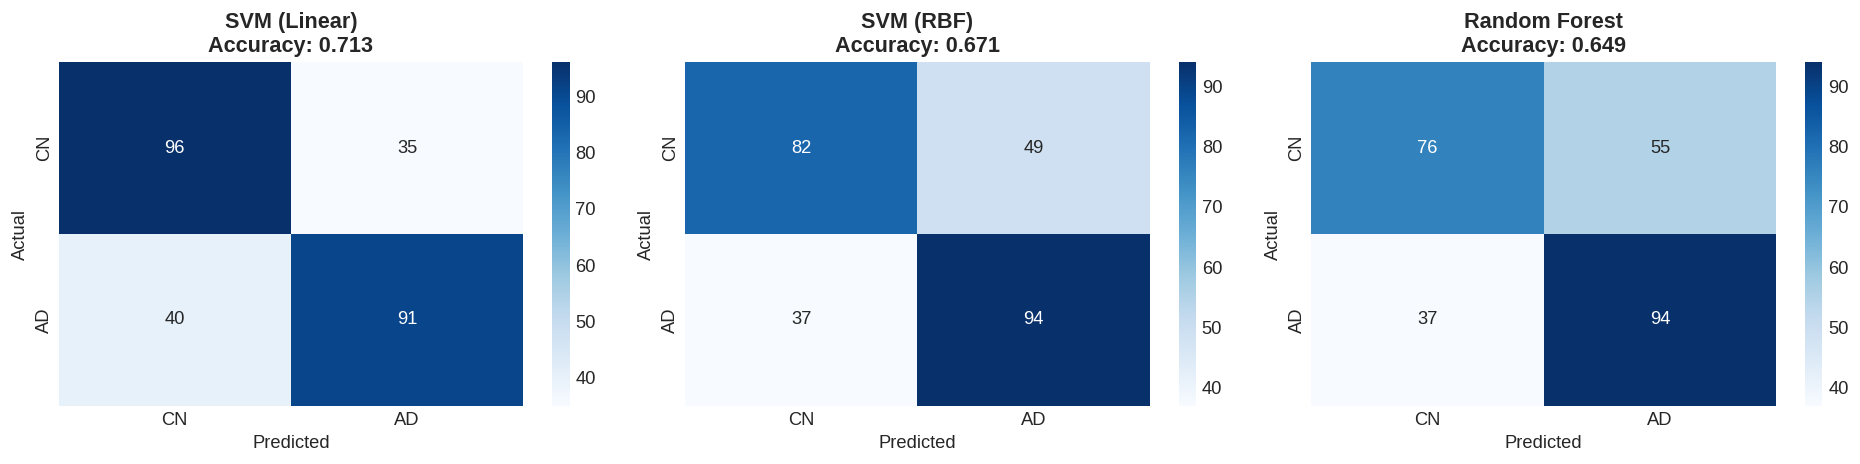

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for idx, r in enumerate(all_results):
    cm = confusion_matrix(r['y_true_all'], r['y_pred_all'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['CN','AD'], yticklabels=['CN','AD'])
    axes[idx].set_title(f"{r['model_name']}\nAccuracy: {r['accuracy_mean']:.3f}")
    axes[idx].set_xlabel('Predicted'); axes[idx].set_ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(NB_FIGURES, 'baseline_confusion_matrices.png'))
plt.show()

### 6.2 ROC Curves

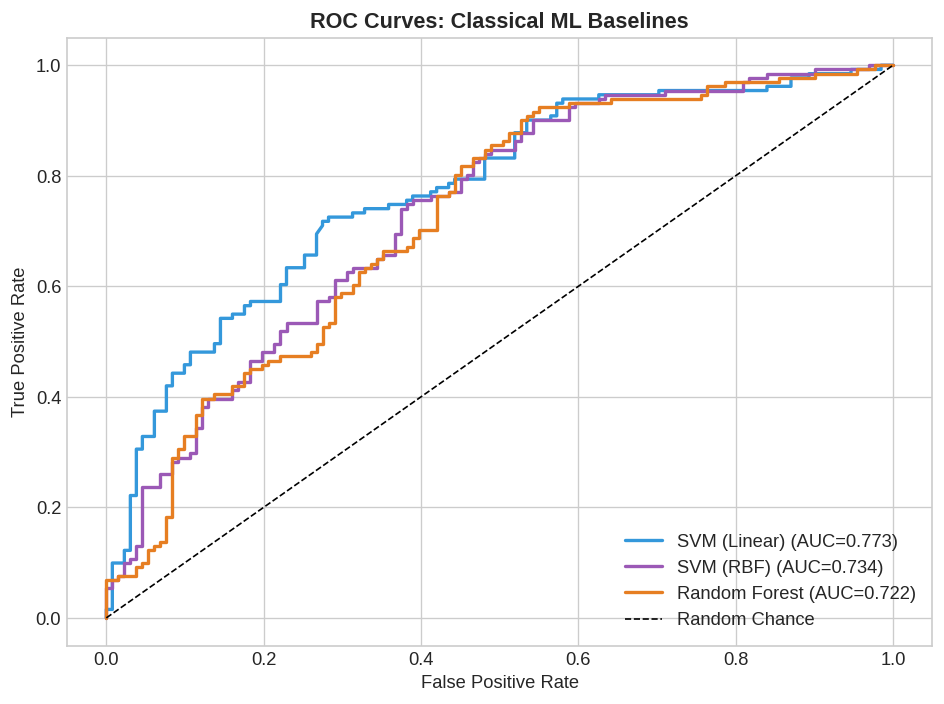

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#3498db', '#9b59b6', '#e67e22']
for idx, r in enumerate(all_results):
    fpr, tpr, _ = roc_curve(r['y_true_all'], r['y_prob_all'])
    ax.plot(fpr, tpr, color=colors_roc[idx], lw=2,
            label=f"{r['model_name']} (AUC={auc(fpr,tpr):.3f})")
ax.plot([0,1],[0,1],'k--',lw=1,label='Random Chance')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves: Classical ML Baselines'); ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(NB_FIGURES, 'baseline_roc_curves.png'))
plt.show()

### 6.3 Per-Fold Accuracy Comparison

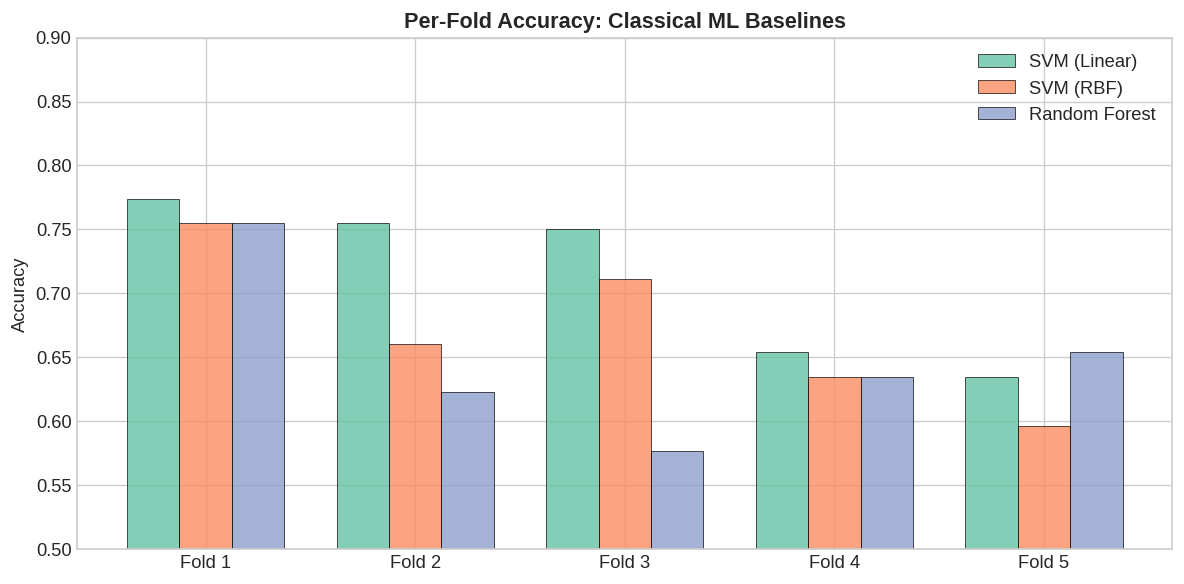

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(5); w = 0.25
for idx, r in enumerate(all_results):
    ax.bar(x+idx*w, r['accuracy_per_fold'], w, label=r['model_name'],
           alpha=0.8, edgecolor='black', linewidth=0.5)
ax.set_xticks(x+w); ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylabel('Accuracy'); ax.set_title('Per-Fold Accuracy: Classical ML Baselines')
ax.legend(); ax.set_ylim(0.5, 0.9)
plt.tight_layout()
plt.savefig(os.path.join(NB_FIGURES, 'baseline_per_fold_accuracy.png'))
plt.show()

## 7. Save All Results

### 7.1 Save Results Pickle

In [ ]:
baseline_save = {
    'svm_linear': svm_lin,
    'svm_rbf': svm_rbf,
    'random_forest': rf,
    'dataset_info': {
        'n_subjects': N, 'n_cn': int((y_fc==0).sum()), 'n_ad': int((y_fc==1).sum()),
        'n_features': X_fc.shape[1], 'n_folds': len(cv_folds),
        'atlas': 'Schaefer100_TianS2', 'n_rois': M,
        'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }
}
pkl_path = os.path.join(NB_RESULTS, 'baseline_results.pkl')
with open(pkl_path, 'wb') as f:
    pickle.dump(baseline_save, f)
print(f'Saved: {pkl_path}')

Saved: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results/nb01_baseline/baseline_results.pkl


### 7.2 Append to Master Summary CSV

In [ ]:
# Create or append to the master summary CSV
summary_csv = os.path.join(RESULTS_BASE, 'all_results_summary.csv')

rows = []
for r in all_results:
    rows.append({
        'model_name': r['model_name'], 'model_type': r['model_type'],
        'n_subjects': r['n_subjects'],
        'accuracy_mean': f"{r['accuracy_mean']:.4f}",
        'accuracy_std': f"{r['accuracy_std']:.4f}",
        'f1_mean': f"{r['f1_mean']:.4f}",
        'f1_std': f"{r['f1_std']:.4f}",
        'auc_roc_mean': f"{r['auc_roc_mean']:.4f}",
        'auc_roc_std': f"{r['auc_roc_std']:.4f}",
        'time_seconds': f"{r['training_time_seconds']:.1f}",
        'notebook': 'nb01_baseline',
        'date': r['date']
    })

new_df = pd.DataFrame(rows)
if os.path.exists(summary_csv):
    existing = pd.read_csv(summary_csv)
    # Remove old baseline entries if re-running
    existing = existing[existing['notebook'] != 'nb01_baseline']
    combined = pd.concat([existing, new_df], ignore_index=True)
else:
    combined = new_df

combined.to_csv(summary_csv, index=False)
print(f'Saved: {summary_csv}')
display(combined.style.set_caption('Master Results Summary').hide(axis='index').\
        set_properties(**{'text-align':'center'}))

Saved: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results/all_results_summary.csv


model_name,model_type,n_subjects,accuracy_mean,accuracy_std,f1_mean,f1_std,auc_roc_mean,auc_roc_std,time_seconds,notebook,date
SVM (Linear),classical_ml,262,0.7134,0.0573,0.7126,0.0572,0.7771,0.0513,4.6,nb01_baseline,2026-08-26 16:28:12
SVM (RBF),classical_ml,262,0.6715,0.0560,0.6697,0.0557,0.7405,0.0762,5.8,nb01_baseline,2026-08-26 16:28:18
Random Forest,classical_ml,262,0.6485,0.0588,0.6445,0.0590,0.7211,0.0594,6.4,nb01_baseline,2026-08-26 16:28:25


### 7.3 Save Markdown Report

In [ ]:
report = os.path.join(NB_RESULTS, 'baseline_report.md')
with open(report, 'w') as f:
    f.write('# Baseline Results Report\n\n')
    f.write(f'**Date:** {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')
    f.write(f'**Dataset:** {N} subjects ({int((y_fc==0).sum())} CN, {int((y_fc==1).sum())} AD), {X_fc.shape[1]} FC features\n')
    f.write(f'**Atlas:** Schaefer 100 + Tian S2 (132 ROIs)\n')
    f.write(f'**Evaluation:** 5-fold stratified CV\n\n')
    f.write('## Results\n\n')
    f.write('| Model | Accuracy | F1 | Precision | Recall | AUC-ROC | Time |\n')
    f.write('|-------|----------|-----|-----------|--------|---------|------|\n')
    for r in all_results:
        f.write(f'| {r["model_name"]} | {r["accuracy_mean"]:.4f}+/-{r["accuracy_std"]:.4f} | '
                f'{r["f1_mean"]:.4f}+/-{r["f1_std"]:.4f} | '
                f'{r["precision_mean"]:.4f}+/-{r["precision_std"]:.4f} | '
                f'{r["recall_mean"]:.4f}+/-{r["recall_std"]:.4f} | '
                f'{r["auc_roc_mean"]:.4f}+/-{r["auc_roc_std"]:.4f} | '
                f'{r["training_time_seconds"]:.1f}s |\n')
    f.write('\n## Figures\n\n')
    for fig_file in sorted(os.listdir(NB_FIGURES)):
        if fig_file.endswith('.png'):
            f.write(f'- {fig_file}\n')
print(f'Saved: {report}')

Saved: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results/nb01_baseline/baseline_report.md


### 7.4 Summary

In [ ]:
best = max(all_results, key=lambda r: r['accuracy_mean'])
n_figs = len([f for f in os.listdir(NB_FIGURES) if f.endswith('.png')])

print('=' * 55)
print('NOTEBOOK COMPLETE')
print('=' * 55)

final = pd.DataFrame({
    'Item': ['Subjects', 'Features', 'ROIs', 'CV Folds', 'Models Trained',
             'Figures Saved', 'Best Model', 'Best Accuracy', 'Best AUC-ROC'],
    'Value': [N, X_fc.shape[1], M, len(cv_folds), len(all_results),
              n_figs, best['model_name'],
              f"{best['accuracy_mean']:.4f} +/- {best['accuracy_std']:.4f}",
              f"{best['auc_roc_mean']:.4f} +/- {best['auc_roc_std']:.4f}"]
})
display(final.style.set_caption('Notebook Summary').hide(axis='index').\
        set_properties(**{'text-align':'left'}))

print(f'\nResults saved to: {NB_RESULTS}')
print(f'  - baseline_results.pkl')
print(f'  - baseline_summary.csv')
print(f'  - baseline_report.md')
print(f'  - demographics_table.csv')
print(f'  - {n_figs} figures in figures/')
print(f'  - Appended to: all_results_summary.csv')


NOTEBOOK COMPLETE


Item,Value
Subjects,262
Features,8646
ROIs,132
CV Folds,5
Models Trained,3
Figures Saved,12
Best Model,SVM (Linear)
Best Accuracy,0.7134 +/- 0.0573
Best AUC-ROC,0.7771 +/- 0.0513



Results saved to: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results/nb01_baseline
  - baseline_results.pkl
  - baseline_summary.csv
  - baseline_report.md
  - demographics_table.csv
  - 12 figures in figures/
  - Appended to: all_results_summary.csv
